In [1]:
# 这个需要用oat那个环境, incluing vllm package
import os

os.environ["HTTP_PROXY"] = "http://webproxy.lab-ia.fr:8080"
os.environ["HTTPS_PROXY"] = "http://webproxy.lab-ia.fr:8080"
os.environ["http_proxy"] = "http://webproxy.lab-ia.fr:8080"
os.environ["https_proxy"] = "http://webproxy.lab-ia.fr:8080"

In [2]:
import torch
print(torch.cuda.device_count())

2


In [3]:
from vllm import LLM, SamplingParams
import torch
import json
from transformers import AutoTokenizer
from tqdm import tqdm
import random
from grader import grade_answer, extract_answer
from collections import defaultdict
from datasets import load_dataset, concatenate_datasets


import argparse
import json
import time
import os
import sys
import re
import copy

/mnt/beegfs/home/han/anaconda3/envs/oat/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 06-04 20:48:52 __init__.py:190] Automatically detected platform cuda.


2025-06-04 20:48:53,029	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [4]:
system_prompt = "You are a helpful assistant. You should think step-by-step and put your final answer within \\boxed{{}}."

def apply_chat_template(example):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": example['problem']}
    ]
    prompt_str = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return {"prompt": prompt_str, "answer": example["answer"]}

In [5]:
model = "Qwen/Qwen2.5-Math-1.5B-Instruct"
check_point_200 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct/checkpoint-200'
check_point_400 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct/checkpoint-400'
check_point_600 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct/checkpoint-600'
check_point_800 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct/checkpoint-800'
check_point_1000 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct/checkpoint-1000'

check_point01_200 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_01/checkpoint-200'
check_point01_400 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_01/checkpoint-400'
check_point01_600 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_01/checkpoint-600'
check_point01_800 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_01/checkpoint-800'
check_point01_1000 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_01/checkpoint-1000'

grpo_200 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_pure/checkpoint-200'
grpo_400 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_pure/checkpoint-400'
grpo_600 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_pure/checkpoint-600'
grpo_800 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_pure/checkpoint-800'
grpo_1000 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/Qwen2.5-Math-1.5B-Instruct_pure/checkpoint-1000'

gpg_check_point_200 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GPG/Qwen2.5-Math-1.5B-Instruct/checkpoint-200'
gpg_check_point_400 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GPG/Qwen2.5-Math-1.5B-Instruct/checkpoint-400'
gpg_check_point_600 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GPG/Qwen2.5-Math-1.5B-Instruct/checkpoint-600'
gpg_check_point_800 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GPG/Qwen2.5-Math-1.5B-Instruct/checkpoint-800'
gpg_check_point_1000 = '/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GPG/Qwen2.5-Math-1.5B-Instruct/checkpoint-1000'

DP_distill_original = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
DP_distill_grpo_800 = "/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/DeepSeek-R1-Distill-Qwen-1.5B_pure/checkpoint-800"
DP_distill_cewe_800 = "/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/DeepSeek-R1-Distill-Qwen-1.5B/checkpoint-800"

testing_model = DP_distill_cewe_800

dataset = load_dataset("knoveleng/AMC-23")["train"]
# dataset = concatenate_datasets([dataset] * 10)
num_samples = 1
n_gpus = torch.cuda.device_count()
max_tokens = 2048

dataset

Dataset({
    features: ['id', 'problem', 'answer', 'url', 'question'],
    num_rows: 40
})

In [6]:
llm = LLM(model=testing_model, tokenizer=testing_model, tensor_parallel_size=n_gpus, max_model_len=max_tokens, dtype="bfloat16")  # half -> float16

INFO 06-04 20:49:32 config.py:542] This model supports multiple tasks: {'embed', 'score', 'reward', 'classify', 'generate'}. Defaulting to 'generate'.
INFO 06-04 20:49:32 config.py:1401] Defaulting to use mp for distributed inference
INFO 06-04 20:49:32 llm_engine.py:234] Initializing a V0 LLM engine (v0.7.2) with config: model='/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/DeepSeek-R1-Distill-Qwen-1.5B/checkpoint-800', speculative_config=None, tokenizer='/mnt/beegfs/home/han/offline_rl/code/GPG/open-r1/output_logs/CEWE/GRPO/DeepSeek-R1-Distill-Qwen-1.5B/checkpoint-800', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=2048, download_dir=None, load_format=auto, tensor_parallel_size=2, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_conf

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:01<00:00,  1.12s/it]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:01<00:00,  1.13s/it]



(VllmWorkerProcess pid=3155) INFO 06-04 20:49:41 model_runner.py:1115] Loading model weights took 1.6901 GB
INFO 06-04 20:49:41 model_runner.py:1115] Loading model weights took 1.6901 GB
(VllmWorkerProcess pid=3155) INFO 06-04 20:49:51 worker.py:267] Memory profiling takes 9.89 seconds
(VllmWorkerProcess pid=3155) INFO 06-04 20:49:51 worker.py:267] the current vLLM instance can use total_gpu_memory (47.53GiB) x gpu_memory_utilization (0.90) = 42.78GiB
(VllmWorkerProcess pid=3155) INFO 06-04 20:49:51 worker.py:267] model weights take 1.69GiB; non_torch_memory takes 0.20GiB; PyTorch activation peak memory takes 0.09GiB; the rest of the memory reserved for KV Cache is 40.80GiB.
INFO 06-04 20:49:51 worker.py:267] Memory profiling takes 10.03 seconds
INFO 06-04 20:49:51 worker.py:267] the current vLLM instance can use total_gpu_memory (47.53GiB) x gpu_memory_utilization (0.90) = 42.78GiB
INFO 06-04 20:49:51 worker.py:267] model weights take 1.69GiB; non_torch_memory takes 0.20GiB; PyTorch a

Capturing CUDA graph shapes: 100%|████████████████████████████████████████| 35/35 [00:31<00:00,  1.10it/s]

INFO 06-04 20:50:29 model_runner.py:1562] Graph capturing finished in 32 secs, took 0.40 GiB
(VllmWorkerProcess pid=3155) INFO 06-04 20:50:29 model_runner.py:1562] Graph capturing finished in 32 secs, took 0.40 GiB
INFO 06-04 20:50:29 llm_engine.py:431] init engine (profile, create kv cache, warmup model) took 48.44 seconds


In [7]:
tokenizer = AutoTokenizer.from_pretrained(model)

In [8]:
logprobs = 5
sampling_params = SamplingParams(temperature=0, seed=42, max_tokens=max_tokens, logprobs=logprobs)

In [9]:
prompts = [apply_chat_template(item) for item in dataset]

In [10]:
outputs = llm.generate(prompts, sampling_params)

Processed prompts: 100%|█| 40/40 [00:31<00:00,  1.25it/s, est. speed input: 179.02 toks/s, output: 1639.74


In [11]:
len(outputs)

40

In [12]:
import numpy as np

correct = count = 0
lengths = []
top_k_entropys = []
for out in outputs:
    top_k_entropy = []
    generations = out.outputs
    
    for i, g in enumerate(generations):
        answer = extract_answer(g.text)
        lengths.append(len(g.text))
        if grade_answer(answer, prompts[count]['answer']):
            correct += 1
    
        for log_porbs in g.logprobs:
            log_prob = np.array([v.logprob for v in log_porbs.values()])
            top_k_entropy = np.sum(- log_prob * np.exp(log_prob))
            
        top_k_entropys.append(np.sum(top_k_entropy))
        count += 1

print(len(lengths))

print('correct:', correct)
print('length:', lengths)
print('accuracy', correct / count)
print('top_k_entropys:', [round(e, 5) for e in top_k_entropys])

40
correct: 18
length: [31, 2425, 275, 4092, 1623, 3178, 4532, 4848, 4240, 3717, 4720, 6218, 4845, 4883, 6764, 5254, 2017, 4177, 6187, 1907, 5617, 3049, 3097, 2690, 3777, 4374, 2543, 4792, 130, 3698, 191, 6200, 4347, 2227, 3546, 80, 424, 5246, 3451, 3568]
accuracy 0.45
top_k_entropys: [0.0031, 0.0, 0.00605, 0.00153, 0.05222, 6e-05, 1.05324, 0.00016, 0.01481, 0.0, 1.32764, 0.0001, 0.01962, 0.00586, 0.06491, 0.00161, 0.0, 4e-05, 0.28157, 0.0, 0.01421, 9e-05, 0.0, 0.0, 0.0, 2e-05, 0.0, 0.06736, 9e-05, 0.0, 0.00591, 0.0, 1.30759, 0.0, 0.01324, 0.00022, 1e-05, 1.2026, 2e-05, 1e-05]


In [13]:
import numpy as np

# Accuracy = 47.5%
Original_lengths = [1172, 978, 828, 1617, 2326, 1702, 2097, 2317, 3639, 1602, 1687, 2436, 2136, 2090, 1805, 1438, 1126, 1293, 6552, 2049, 3006, 1405, 2064, 1801, 2248, 1430, 1814, 2026, 1790, 1684, 1025, 9434, 2062, 1349, 1122, 1840, 1875, 2505, 1510, 2012]
Original_entropys = [2e-05, 0.00057, 0.00031, 4e-05, 0.06213, 0.00336, 0.00429, 0.29807, 0.00889, 0.0027, 0.01261, 0.01689, 0.00089, 0.00076, 6e-05, 3e-05, 1e-05, 4e-05, 0.00019, 0.00821, 0.03791, 0.00201, 0.00043, 0.00016, 0.0207, 0.00027, 0.00016, 0.01206, 0.02243, 0.00669, 8e-05, 0.25094, 0.00107, 0.00117, 3e-05, 0.00684, 0.00833, 0.00207, 0.0368, 0.003]

# Accuracy = 50%
checkpoint_200_lengths = [1153, 964, 828, 1616, 2911, 1902, 1871, 3665, 2910, 1588, 1486, 2256, 2050, 2463, 1801, 1077, 800, 1206, 1823, 1677, 2416, 1400, 1299, 1891, 2300, 1363, 1301, 2005, 2561, 1684, 1025, 2975, 2036, 1335, 1122, 1733, 2151, 2430, 1162, 1994]
checkpoint_200_entropys = [2e-05, 0.00188, 0.00035, 5e-05, 0.05983, 0.0024, 0.0013, 2e-05, 0.00632, 0.0043, 0.00068, 0.00487, 4e-05, 0.00645, 8e-05, 0.00013, 0.00423, 5e-05, 0.00114, 0.00128, 0.00918, 0.00216, 3e-05, 0.00014, 0.01292, 0.0001, 4e-05, 0.06777, 0.0431, 0.00707, 7e-05, 0.00843, 0.00022, 0.00114, 3e-05, 0.00488, 0.00445, 0.0011, 0.00694, 0.00312]

# Accuracy = 55.0%
checkpoint_400_lengths = [943, 1030, 754, 1436, 2069, 1579, 2278, 3656, 2774, 1588, 1473, 2130, 2126, 1609, 957, 1211, 763, 1164, 3190, 1544, 2245, 1400, 1296, 2048, 1723, 6637, 1268, 1936, 2051, 1643, 947, 2205, 2640, 1269, 936, 2257, 2351, 2176, 1341, 1994]
checkpoint_400_entropys = [8e-05, 0.00188, 0.0013, 0.00024, 0.07395, 0.00093, 0.00066, 1e-05, 0.01927, 0.00625, 0.00099, 0.00637, 0.00025, 0.00065, 3e-05, 7e-05, 0.00102, 0.00022, 0.01474, 0.00053, 0.00358, 0.00295, 4e-05, 0.00018, 0.00492, 0.15834, 3e-05, 0.04888, 0.00577, 0.00773, 5e-05, 0.09448, 0.00034, 0.00179, 4e-05, 0.01412, 0.02703, 0.00011, 0.04707, 0.00434]

# Accuracy = 50%
checkpoint_600_lengths = [931, 779, 754, 1321, 3246, 1411, 1961, 1358, 1940, 1553, 1678, 2419, 1583, 3974, 1845, 1333, 770, 1064, 3086, 1406, 3671, 1394, 1279, 1919, 1507, 1760, 1245, 1694, 2087, 1316, 595, 1919, 1953, 1228, 936, 1727, 1816, 2048, 906, 1673]
checkpoint_600_entropys = [5e-05, 0.00105, 0.00134, 0.00014, 0.00093, 0.00433, 0.00276, 0.00148, 0.01878, 0.00266, 0.00042, 0.00151, 0.00181, 0.00045, 2e-05, 0.00017, 6e-05, 1e-05, 0.34687, 0.00016, 0.00412, 0.00382, 6e-05, 0.00019, 0.00423, 0.00036, 2e-05, 0.00469, 0.00885, 0.0005, 1e-05, 0.00084, 0.00013, 0.00179, 4e-05, 0.00528, 0.00072, 0.00084, 0.05131, 0.00422]

# Accuracy = 55%
checkpoint_800_lengths = [924, 762, 754, 1232, 1955, 1421, 1765, 1305, 1915, 1666, 1511, 3151, 1987, 1718, 1728, 1241, 721, 1062, 1936, 1341, 2072, 1394, 1658, 2790, 1512, 1136, 1167, 1466, 1828, 1300, 525, 1921, 1698, 1228, 1083, 2385, 1522, 2048, 906, 1899]
checkpoint_800_entropys = [6e-05, 0.00226, 0.00134, 0.00067, 0.05553, 0.00376, 0.00126, 0.0023, 0.03405, 0.00244, 0.00094, 0.00979, 0.00161, 0.00049, 5e-05, 0.00023, 0.0005, 1e-05, 0.00873, 0.00021, 0.00427, 0.0041, 0.00058, 0.08978, 0.00169, 0.00027, 4e-05, 0.00033, 0.00286, 0.00058, 2e-05, 0.00094, 0.00011, 0.00174, 1e-05, 0.02981, 0.00257, 0.00075, 0.05343, 0.00457]

# Accuracy = 52.5%
checkpoint_1000_lengths = [924, 748, 754, 1232, 1955, 1421, 1765, 1305, 1988, 1666, 1473, 2132, 1987, 1718, 1739, 1241, 746, 958, 3348, 1477, 1134, 1392, 1565, 1801, 1512, 1073, 1167, 1466, 1790, 1300, 525, 4957, 1693, 1228, 1083, 2246, 1522, 1982, 906, 1555]
checkpoint_1000_entropys = [7e-05, 0.00174, 0.00134, 0.00064, 0.05169, 0.00422, 0.00126, 0.00214, 0.04972, 0.00244, 0.00088, 0.00548, 0.00158, 0.00049, 5e-05, 0.00024, 4e-05, 8e-05, 0.00104, 0.00065, 0.00041, 0.00356, 0.00029, 0.00143, 0.00161, 0.00028, 4e-05, 0.00034, 0.00273, 0.00052, 2e-05, 0.00013, 0.00022, 0.00179, 1e-05, 0.00995, 0.00248, 0.00032, 0.05107, 0.00707]



In [14]:
window_size = 5

Avg_Original_lengths = np.convolve(Original_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_200_lengths = np.convolve(checkpoint_200_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_400_lengths = np.convolve(checkpoint_400_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_600_lengths = np.convolve(checkpoint_600_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_800_lengths = np.convolve(checkpoint_800_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_1000_lengths = np.convolve(checkpoint_1000_lengths, np.ones(window_size)/window_size, mode='valid')

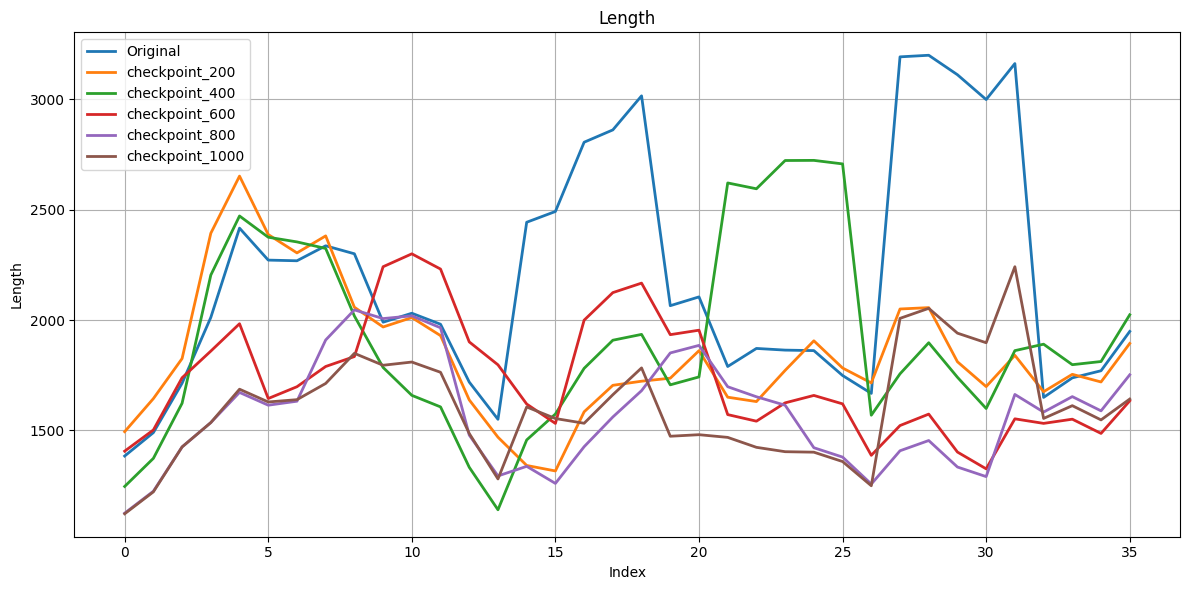

In [15]:
import matplotlib.pyplot as plt

# 绘制曲线图
plt.figure(figsize=(12, 6))
plt.plot(Avg_Original_lengths, label="Original", linewidth=2)
plt.plot(Avg_checkpoint_200_lengths, label="checkpoint_200", linewidth=2)
plt.plot(Avg_checkpoint_400_lengths, label="checkpoint_400", linewidth=2)
plt.plot(Avg_checkpoint_600_lengths, label="checkpoint_600", linewidth=2)
plt.plot(Avg_checkpoint_800_lengths, label="checkpoint_800", linewidth=2)
plt.plot(Avg_checkpoint_1000_lengths, label="checkpoint_1000", linewidth=2)
# 图例和标签
plt.title("Length")
plt.xlabel("Index")
plt.ylabel("Length")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
window_size = 50

Avg_Original_entropys = np.convolve(Original_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_200_entropys = np.convolve(checkpoint_200_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_400_entropys = np.convolve(checkpoint_400_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_600_entropys = np.convolve(checkpoint_600_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_800_entropys = np.convolve(checkpoint_800_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint_1000_entropys = np.convolve(checkpoint_1000_entropys, np.ones(window_size)/window_size, mode='valid')

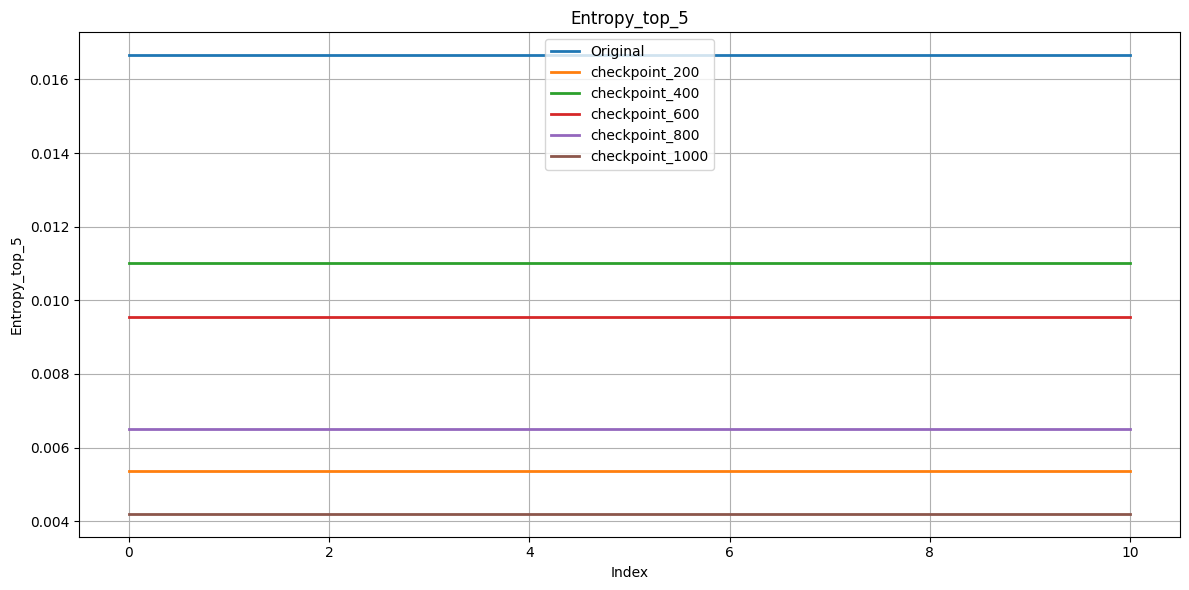

In [17]:
import matplotlib.pyplot as plt

# 绘制曲线图
plt.figure(figsize=(12, 6))
plt.plot(Avg_Original_entropys, label="Original", linewidth=2)
plt.plot(Avg_checkpoint_200_entropys, label="checkpoint_200", linewidth=2)
plt.plot(Avg_checkpoint_400_entropys, label="checkpoint_400", linewidth=2)
plt.plot(Avg_checkpoint_600_entropys, label="checkpoint_600", linewidth=2)
plt.plot(Avg_checkpoint_800_entropys, label="checkpoint_800", linewidth=2)
plt.plot(Avg_checkpoint_1000_entropys, label="checkpoint_1000", linewidth=2)
# 图例和标签
plt.title("Entropy_top_5")
plt.xlabel("Index")
plt.ylabel("Entropy_top_5")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:

# Accuracy = 50%
checkpoint01_200_lengths = [1153, 1337, 833, 1442, 2002, 1902, 2074, 3665, 2987, 1588, 1671, 3249, 2112, 2008, 1801, 1444, 760, 1239, 2121, 1544, 3030, 1400, 1494, 1884, 2168, 5584, 1265, 1571, 2468, 1643, 1025, 1819, 2079, 1312, 1008, 1733, 1984, 2336, 1492, 1994]
checkpoint01_200_entropys = [1e-05, 0.00176, 0.00047, 0.00016, 0.04952, 0.00236, 0.00438, 2e-05, 0.01635, 0.00463, 0.00083, 0.13277, 0.00019, 0.00018, 7e-05, 2e-05, 0.00093, 4e-05, 0.01546, 0.00032, 0.00018, 0.00215, 5e-05, 0.00016, 0.00298, 0.00774, 1e-05, 0.00093, 0.00679, 0.00598, 5e-05, 0.00059, 0.00019, 0.00105, 1e-05, 0.00483, 0.0079, 0.00185, 0.02727, 0.00299]

# Accuracy = 50%
checkpoint01_400_lengths = [792, 734, 754, 945, 1955, 1319, 1717, 1678, 3694, 1544, 1473, 2157, 1856, 3971, 1756, 1207, 800, 834, 1902, 1406, 2221, 1208, 1929, 2096, 1512, 2129, 1238, 1468, 2014, 1542, 564, 1981, 2423, 1224, 1083, 2534, 1821, 1999, 940, 1904]
checkpoint01_400_entropys = [0.0, 0.00122, 0.00095, 4e-05, 0.04485, 0.00024, 0.01094, 0.00137, 0.0045, 0.00147, 0.00079, 0.00248, 0.00068, 2e-05, 3e-05, 5e-05, 0.00058, 2e-05, 0.00636, 9e-05, 0.00548, 0.00025, 5e-05, 0.00199, 0.00099, 0.01722, 2e-05, 0.00103, 0.00406, 0.00104, 1e-05, 0.00039, 0.00017, 0.00088, 1e-05, 0.0393, 0.0015, 0.00014, 0.04076, 0.00287]

# Accuracy = 62.5%
checkpoint01_600_lengths = [709, 667, 735, 940, 1825, 1107, 1362, 1922, 2141, 1334, 1727, 3203, 1725, 3502, 1717, 1014, 714, 746, 1198, 1149, 2741, 850, 1189, 1674, 1577, 1095, 1156, 1363, 2014, 1796, 498, 1755, 2011, 1183, 722, 2188, 1523, 1705, 1002, 1448]
checkpoint01_600_entropys = [1e-05, 0.00065, 0.00086, 0.00011, 0.04051, 0.00724, 0.00021, 0.00038, 0.01788, 0.00086, 0.01036, 0.00577, 0.00035, 0.00021, 4e-05, 5e-05, 7e-05, 6e-05, 0.0038, 0.00012, 0.03626, 0.00039, 0.00033, 5e-05, 0.00032, 0.00019, 3e-05, 0.00059, 0.00293, 0.00193, 2e-05, 0.00379, 0.00047, 0.00093, 2e-05, 0.02595, 0.00251, 0.0001, 0.01438, 0.00275]

# Accuracy = 52.5%
checkpoint01_800_lengths = [709, 641, 731, 968, 1710, 995, 1232, 1834, 2501, 1116, 1041, 2978, 1371, 2155, 1403, 1069, 714, 746, 1109, 1090, 677, 853, 1212, 1636, 1548, 1159, 1011, 1443, 1576, 1753, 491, 2187, 1473, 1181, 661, 1685, 1653, 1693, 1379, 1309]
checkpoint01_800_entropys = [1e-05, 0.00094, 0.00019, 4e-05, 0.03414, 0.00574, 0.0006, 0.00098, 0.00316, 0.00052, 0.0, 0.00308, 9e-05, 0.00054, 1e-05, 0.00014, 7e-05, 5e-05, 0.00391, 0.00038, 0.00013, 0.00036, 0.00028, 8e-05, 0.00067, 9e-05, 4e-05, 0.00068, 0.00065, 0.00175, 2e-05, 0.00284, 0.00031, 0.00074, 2e-05, 0.00177, 0.00385, 0.00037, 0.01246, 0.00322]

# Accuracy = 47.5%
checkpoint01_1000_lengths = [709, 641, 731, 968, 1722, 995, 1284, 1343, 2825, 1079, 1041, 2146, 1371, 1187, 805, 986, 714, 746, 1206, 1096, 2058, 853, 1212, 1636, 1533, 1346, 1011, 1453, 1368, 1613, 491, 1657, 1473, 1183, 661, 1677, 1653, 1693, 1379, 1243]
checkpoint01_1000_entropys = [1e-05, 0.00079, 0.00018, 5e-05, 0.03041, 0.00358, 0.00013, 0.00076, 0.01378, 0.0007, 0.0, 0.01016, 9e-05, 0.00126, 4e-05, 4e-05, 8e-05, 5e-05, 0.00105, 0.00047, 0.00395, 0.00038, 0.00029, 7e-05, 0.0005, 3e-05, 4e-05, 0.00064, 0.00161, 0.00434, 2e-05, 0.0001, 0.00026, 0.00096, 2e-05, 0.00213, 0.00401, 0.00038, 0.01255, 0.00349]

In [19]:
window_size = 5

Avg_Original_lengths = np.convolve(Original_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_200_lengths = np.convolve(checkpoint01_200_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_400_lengths = np.convolve(checkpoint01_400_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_600_lengths = np.convolve(checkpoint01_600_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_800_lengths = np.convolve(checkpoint01_800_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_1000_lengths = np.convolve(checkpoint01_1000_lengths, np.ones(window_size)/window_size, mode='valid')

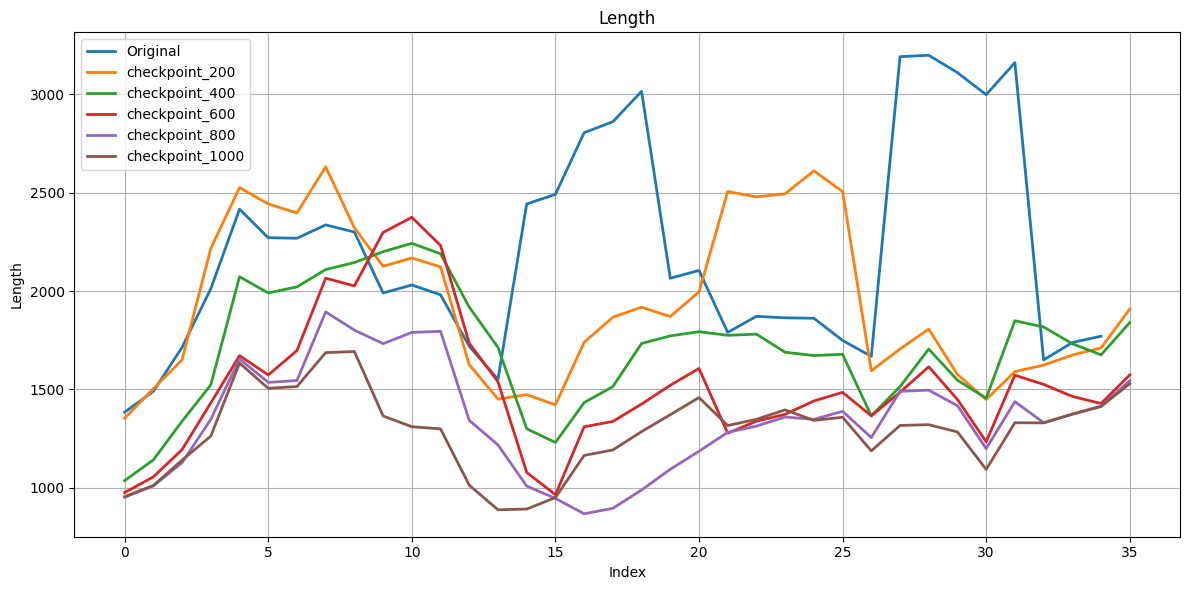

In [20]:
import matplotlib.pyplot as plt

# 绘制曲线图
plt.figure(figsize=(12, 6))
plt.plot(Avg_Original_lengths[:35], label="Original", linewidth=2)
plt.plot(Avg_checkpoint01_200_lengths, label="checkpoint_200", linewidth=2)
plt.plot(Avg_checkpoint01_400_lengths, label="checkpoint_400", linewidth=2)
plt.plot(Avg_checkpoint01_600_lengths, label="checkpoint_600", linewidth=2)
plt.plot(Avg_checkpoint01_800_lengths, label="checkpoint_800", linewidth=2)
plt.plot(Avg_checkpoint01_1000_lengths, label="checkpoint_1000", linewidth=2)
# 图例和标签
plt.title("Length")
plt.xlabel("Index")
plt.ylabel("Length")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
window_size = 5

Avg_Original_lengths = np.convolve(Original_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_200_entropys = np.convolve(checkpoint01_200_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_400_entropys = np.convolve(checkpoint01_400_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_600_entropys = np.convolve(checkpoint01_600_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_800_entropys = np.convolve(checkpoint01_800_entropys, np.ones(window_size)/window_size, mode='valid')
Avg_checkpoint01_1000_entropys = np.convolve(checkpoint01_1000_entropys, np.ones(window_size)/window_size, mode='valid')

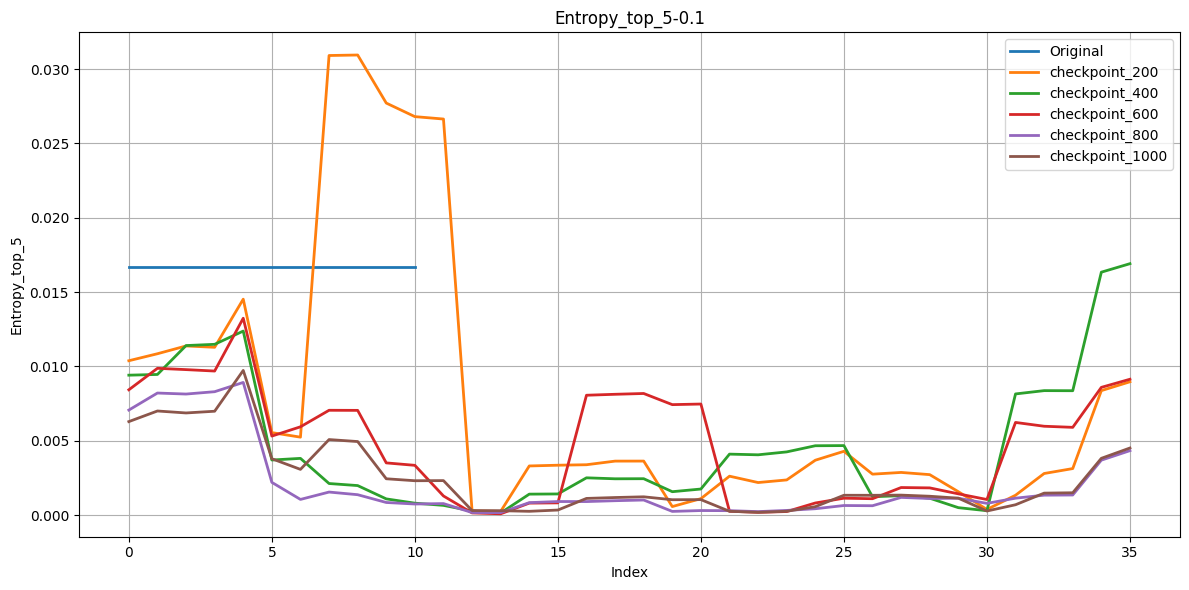

In [22]:
import matplotlib.pyplot as plt

# 绘制曲线图
plt.figure(figsize=(12, 6))
plt.plot(Avg_Original_entropys, label="Original", linewidth=2)
plt.plot(Avg_checkpoint01_200_entropys, label="checkpoint_200", linewidth=2)
plt.plot(Avg_checkpoint01_400_entropys, label="checkpoint_400", linewidth=2)
plt.plot(Avg_checkpoint01_600_entropys, label="checkpoint_600", linewidth=2)
plt.plot(Avg_checkpoint01_800_entropys, label="checkpoint_800", linewidth=2)
plt.plot(Avg_checkpoint01_1000_entropys, label="checkpoint_1000", linewidth=2)
# 图例和标签
plt.title("Entropy_top_5-0.1")
plt.xlabel("Index")
plt.ylabel("Entropy_top_5")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
# GRPO
# Accuracy = 50.0%
GRPO_200_lengths = [1190, 1373, 828, 1420, 2088, 1893, 2082, 1992, 3482, 1602, 1792, 2953, 2194, 2493, 1805, 1337, 1084, 1275, 2903, 1903, 2341, 1400, 1484, 2002, 2280, 1469, 1666, 1644, 2373, 1591, 1052, 9170, 3424, 1378, 1122, 1840, 1640, 2499, 1510, 2010]
GRPO_200_entropys = [2e-05, 0.00163, 0.00032, 5e-05, 0.0327, 0.00353, 0.00506, 0.01834, 0.01947, 0.00271, 0.0007, 0.01189, 0.00141, 0.00053, 5e-05, 3e-05, 0.00038, 0.00017, 0.00689, 0.00605, 0.0017, 0.00234, 0.00046, 0.00014, 0.01468, 0.0005, 3e-05, 0.00454, 0.00534, 0.00461, 8e-05, 0.00254, 0.00031, 0.00061, 2e-05, 0.0071, 0.01645, 0.00221, 0.0349, 0.00919]

# Accuracy = 50.0%
GRPO_400_lengths = [1172, 2183, 828, 1420, 2760, 1565, 2101, 2330, 3094, 1602, 1676, 2923, 2124, 3459, 1806, 1337, 1084, 1166, 3137, 1767, 2351, 1400, 1737, 3031, 2280, 1469, 1814, 2035, 2736, 1591, 1058, 3286, 2285, 1349, 1007, 1740, 1984, 2497, 1346, 1917]
GRPO_400_entropys = [2e-05, 0.00151, 0.00031, 4e-05, 0.10795, 0.00117, 0.00662, 0.31277, 0.00662, 0.00263, 0.00629, 0.01304, 0.00087, 0.00025, 0.0002, 3e-05, 0.00042, 0.00041, 0.01097, 0.00184, 0.0041, 0.00253, 0.00056, 0.03977, 0.01521, 0.00045, 0.00021, 0.0047, 0.01137, 0.00487, 7e-05, 0.90298, 0.20196, 0.00132, 0.0, 0.00362, 0.00923, 0.00219, 0.05047, 0.00421]

# Accuracy = 50.0%
GRPO_600_lengths = [1172, 2183, 828, 1384, 2437, 1913, 2069, 2431, 3099, 1602, 2157, 2910, 2123, 3459, 1830, 2863, 1084, 1166, 5298, 1766, 2698, 1400, 1737, 2959, 2280, 1469, 1814, 2035, 1506, 1660, 1058, 1866, 3489, 1349, 1122, 1740, 1942, 2505, 1485, 2129]
GRPO_600_entropys = [2e-05, 0.00152, 0.00028, 5e-05, 0.09883, 0.00388, 0.0063, 0.03736, 0.0074, 0.00256, 0.01156, 0.02145, 0.00085, 0.00022, 0.00015, 0.00427, 0.00048, 0.00042, 0.08633, 0.00194, 0.00495, 0.00231, 0.00053, 0.04198, 0.01467, 0.00049, 0.00019, 0.0049, 0.0025, 0.00575, 7e-05, 0.00951, 0.00102, 0.00135, 2e-05, 0.00339, 0.00681, 0.00187, 0.02547, 0.03264]

# Accuracy = 57.5%
GRPO_800_lengths = [1172, 1454, 828, 1420, 2034, 1565, 2113, 2785, 3206, 1602, 1676, 2517, 2123, 2090, 1777, 1340, 1084, 1125, 2739, 1936, 2698, 1400, 1682, 2469, 2248, 1481, 1814, 1623, 2121, 1591, 1058, 1866, 2042, 1351, 1008, 1740, 1984, 2499, 1485, 1917]
GRPO_800_entropys = [2e-05, 0.002, 0.00029, 4e-05, 0.04948, 0.00131, 0.00521, 0.03249, 0.00889, 0.0027, 0.00654, 0.00221, 0.00084, 0.00071, 8e-05, 0.00049, 0.00056, 0.00013, 0.01694, 0.00079, 0.00468, 0.00232, 0.00038, 0.00745, 0.02303, 0.00056, 0.00017, 0.00218, 0.00517, 0.0046, 7e-05, 0.00991, 0.0002, 0.00088, 1e-05, 0.00369, 0.00916, 0.00176, 0.02841, 0.00453]

# # Accuracy = 47.5%
GRPO_1000_lengths = [1172, 2166, 828, 1420, 2034, 1565, 2069, 2785, 3190, 1602, 1917, 2904, 2112, 2090, 1805, 1340, 1084, 1125, 6552, 1752, 3392, 1400, 1434, 3031, 2320, 1481, 1814, 1644, 2736, 1684, 1058, 3104, 3601, 1335, 1122, 1932, 1984, 2497, 1510, 2129]
GRPO_1000_entropys = [2e-05, 0.0021, 0.0003, 5e-05, 0.05251, 0.0012, 0.00595, 0.03252, 0.00766, 0.00263, 0.00339, 0.01519, 0.00019, 0.0008, 5e-05, 0.00048, 0.00046, 0.00012, 0.00019, 0.00224, 0.03302, 0.00214, 4e-05, 0.03975, 0.0164, 0.00053, 0.00019, 0.00111, 0.01032, 0.0062, 7e-05, 0.00287, 0.00025, 0.00108, 2e-05, 0.16383, 0.0088, 0.00197, 0.03708, 0.03352]



In [24]:
window_size = 5

Avg_Original_lengths = np.convolve(Original_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_grpo_200_lengths = np.convolve(GRPO_200_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_grpo_400_lengths = np.convolve(GRPO_400_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_grpo_600_lengths = np.convolve(GRPO_600_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_grpo_800_lengths = np.convolve(GRPO_800_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_grpo_1000_lengths = np.convolve(GRPO_1000_lengths, np.ones(window_size)/window_size, mode='valid')


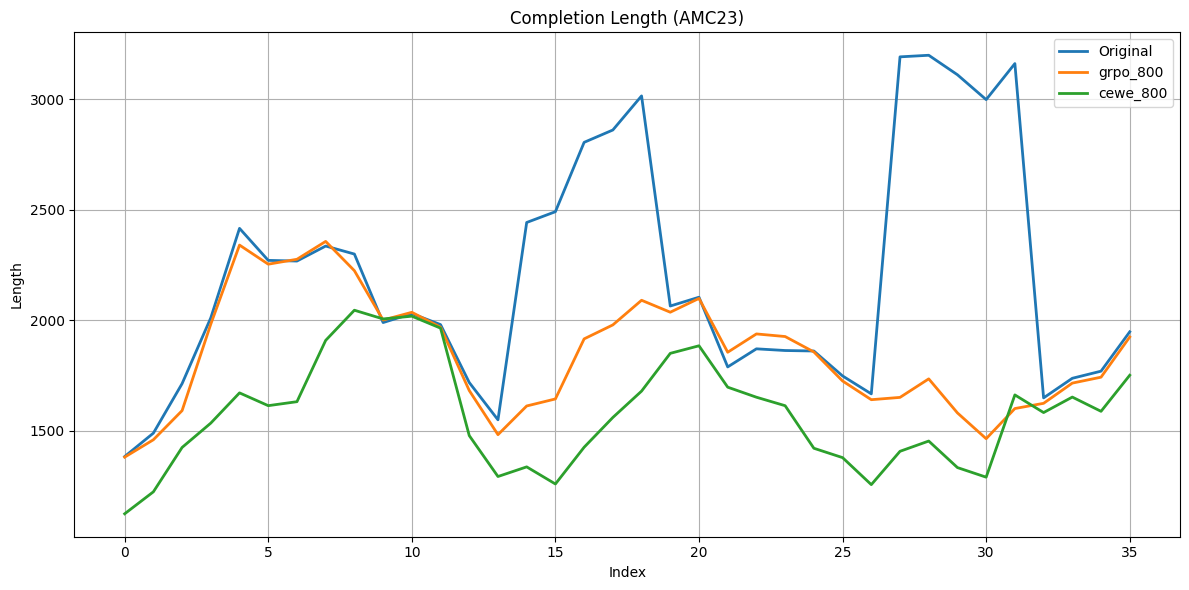

In [25]:
import matplotlib.pyplot as plt

# 绘制曲线图
plt.figure(figsize=(12, 6))
plt.plot(Avg_Original_lengths, label="Original", linewidth=2)
plt.plot(Avg_grpo_800_lengths, label="grpo_800", linewidth=2)
plt.plot(Avg_checkpoint_800_lengths, label="cewe_800", linewidth=2)

# 图例和标签
plt.title("Completion Length (AMC23)")
plt.xlabel("Index")
plt.ylabel("Length")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
import numpy as np

# Accuracy = 47.5%
Original_lengths = [1172, 978, 828, 1617, 2326, 1702, 2097, 2317, 3639, 1602, 1687, 2436, 2136, 2090, 1805, 1438, 
                    1126, 1293, 6552, 2049, 3006, 1405, 2064, 1801, 2248, 1430, 1814, 2026, 1790, 1684, 1025, 9434, 2062, 1349, 1122, 1840, 1875, 2505, 1510, 2012]
Original_entropys = [2e-05, 0.00057, 0.00031, 4e-05, 0.06213, 0.00336, 0.00429, 0.29807, 0.00889, 0.0027, 0.01261, 
                     0.01689, 0.00089, 0.00076, 6e-05, 3e-05, 1e-05, 4e-05, 0.00019, 0.00821, 0.03791, 0.00201, 0.00043, 0.00016, 0.0207, 0.00027, 0.00016, 0.01206, 0.02243, 0.00669, 8e-05, 0.25094, 0.00107, 0.00117, 3e-05, 0.00684, 0.00833, 0.00207, 0.0368, 0.003]

# Accuracy = 52.5%
gpg_checkpoint_200_lengths = [1169, 1337, 828, 1617, 2729, 1902, 2726, 2317, 2761, 1588, 2155, 2403, 2112, 2090, 1805, 
                               1441, 800, 1075, 1823, 1703, 2917, 1400, 1625, 1966, 2268, 1321, 1313, 2011, 2670, 1684, 1025, 1819, 2079, 1335, 1008, 1733, 1943, 2430, 1506, 1994] 
gpg_checkpoint_200_entropys = [2e-05, 0.00186, 0.00032, 5e-05, 0.10795, 0.00244, 0.00875, 0.30224, 0.0035, 0.00405, 0.01082, 0.0098, 0.00019, 0.00086, 7e-05, 3e-05, 0.00664, 7e-05, 0.0011, 0.00105, 0.01686, 0.0022, 0.00043, 0.00018, 0.01443, 
                               0.00028, 2e-05, 0.06037, 0.00348, 0.00707, 6e-05, 0.00073, 0.00019, 0.00099, 1e-05, 0.00462, 0.00929, 0.00099, 0.0322, 0.00331]

# Accuracy = 65.0%
gpg_checkpoint_400_lengths = [1127, 1077, 754, 1442, 2026, 1902, 2352, 3669, 2772, 1588, 1748, 2173, 2111, 2055, 1730, 1216, 763, 1239, 2329, 1506, 2430, 1398, 1494, 1877, 
                               2261, 1510, 1268, 1766, 1607, 1620, 1021, 1732, 2300, 1312, 906, 1713, 1859, 2304, 1492, 1994]
gpg_checkpoint_400_entropys = [1e-05, 0.00548, 0.00113, 0.00019, 0.03788, 0.00264, 0.01005, 0.0, 0.01061, 0.005, 0.00115, 0.00447, 
                               0.00017, 0.00021, 1e-05, 5e-05, 0.00228, 6e-05, 0.01554, 0.00025, 0.05862, 0.00156, 6e-05, 0.0006, 0.00947, 3e-05, 2e-05, 0.00114, 0.0015, 0.00565, 3e-05, 0.00025, 0.00049, 0.00124, 2e-05, 0.0046, 0.00155, 0.00035, 0.02958, 0.00352]

# Accuracy = 50.0%
gpg_checkpoint_600_lengths = [943, 763, 754, 1318, 2026, 1591, 1356, 3612, 2859, 1553, 1473, 2662, 2005, 3974, 1756, 1207, 772, 1096, 3063, 1513, 
                               1928, 1392, 1784, 1893, 1723, 1700, 1251, 1214, 4578, 1324, 947, 1923, 2211, 1269, 1132, 2270, 1775, 2418, 1161, 1537]
gpg_checkpoint_600_entropys = [7e-05, 0.00246, 0.00123, 1e-05, 0.03821, 0.00189, 0.0009, 0.00049, 0.03233, 0.00201, 0.00078, 0.00112, 0.00013, 0.00039, 
                               3e-05, 5e-05, 0.00035, 2e-05, 0.40817, 0.00027, 0.00382, 0.00167, 4e-05, 0.00052, 0.00372, 0.00168, 3e-05, 0.00067, 0.00643, 0.00044, 4e-05, 0.0004, 0.00013, 0.0016, 1e-05, 0.00727, 0.00044, 0.00064, 0.02319, 0.00673]

# Accuracy = 50.0%
gpg_checkpoint_800_lengths = [924, 766, 754, 1142, 3234, 1738, 2285, 1682, 3697, 1553, 1686, 2229, 2013, 3974, 1728, 1207, 772, 
                               846, 3063, 1513, 1635, 1398, 1755, 1875, 1705, 1808, 1238, 1370, 2797, 1324, 564, 1886, 2561, 1269, 885, 2259, 1799, 2086, 1036, 1541]
gpg_checkpoint_800_entropys = [5e-05, 0.00208, 0.00116, 1e-05, 0.00234, 0.00264, 0.00066, 0.00164, 0.00054, 0.00207, 0.00053, 0.00061, 0.00012, 0.00038, 4e-05, 6e-05, 
                               0.00041, 2e-05, 0.3773, 0.00024, 0.00032, 0.00165, 0.00096, 0.00067, 0.00459, 0.00029, 4e-05, 0.00094, 0.0003, 0.00044, 1e-05, 0.00208, 0.00013, 0.00169, 1e-05, 0.00873, 0.00053, 0.00016, 0.02912, 0.00714]

# Accuracy = 55.0%
gpg_checkpoint_1000_lengths = [900, 766, 754, 1307, 1974, 1738, 2285, 1701, 3697, 1553, 1473, 2441, 1911, 3974, 1728, 1317, 772, 834, 3063, 1513, 2270, 1392, 1386, 
                               1875, 1705, 1689, 1251, 1531, 1667, 1324, 564, 2725, 2491, 1269, 885, 2259, 1775, 1762, 1036, 1504]
gpg_checkpoint_1000_entropys = [4e-05, 0.00221, 0.00104, 1e-05, 0.04621, 0.00269, 0.00066, 0.00537, 0.00054, 0.00201, 0.00082, 0.00118, 6e-05, 0.00038, 4e-05, 
                                0.00015, 0.00037, 2e-05, 0.37721, 0.00027, 0.00658, 0.00167, 8e-05, 0.00058, 0.0038, 0.00016, 3e-05, 0.0028, 0.00167, 0.00048, 1e-05, 0.05376, 0.00014, 0.00143, 1e-05, 0.00883, 0.00051, 8e-05, 0.0253, 0.00131]

In [27]:
window_size = 5

Avg_Original_lengths = np.convolve(Original_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_gpg_200_lengths = np.convolve(gpg_checkpoint_200_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_gpg_400_lengths = np.convolve(gpg_checkpoint_400_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_gpg_600_lengths = np.convolve(gpg_checkpoint_600_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_gpg_800_lengths = np.convolve(gpg_checkpoint_800_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_gpg_1000_lengths = np.convolve(gpg_checkpoint_1000_lengths, np.ones(window_size)/window_size, mode='valid')

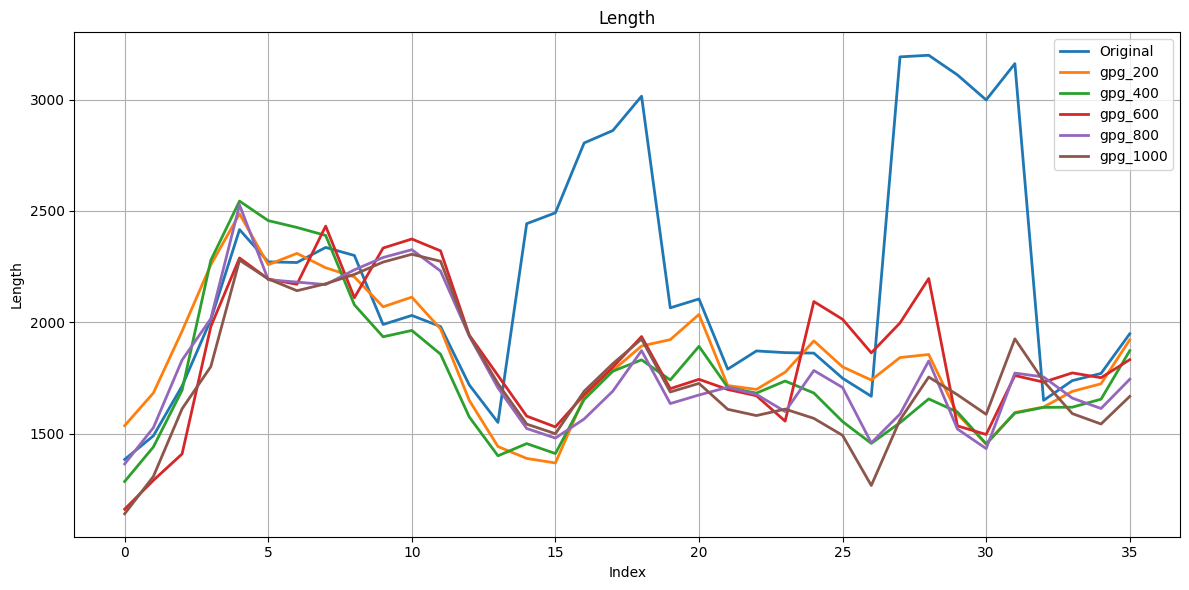

In [28]:
import matplotlib.pyplot as plt

# 绘制曲线图
plt.figure(figsize=(12, 6))
plt.plot(Avg_Original_lengths, label="Original", linewidth=2)
plt.plot(Avg_gpg_200_lengths, label="gpg_200", linewidth=2)
plt.plot(Avg_gpg_400_lengths, label="gpg_400", linewidth=2)
plt.plot(Avg_gpg_600_lengths, label="gpg_600", linewidth=2)
plt.plot(Avg_gpg_800_lengths, label="gpg_800", linewidth=2)
plt.plot(Avg_gpg_1000_lengths, label="gpg_1000", linewidth=2)
# 图例和标签
plt.title("Length")
plt.xlabel("Index")
plt.ylabel("Length")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
# DeepSeek-R1-Distill-Qwen-1.5B

# Accuracy = 27.5%
Original_lengths = [3006, 5431, 2498, 4425, 5600, 5966, 4636, 4850, 4503, 4703, 4099, 6568, 5184, 5524, 4363, 5616, 5266, 4795, 6565, 4833, 6041, 4363, 5184, 5280, 5389, 4790, 4139, 5784, 4231, 4943, 3202, 6564, 4595, 4249, 5555, 5795, 6523, 5333, 5809, 5963]
Original_entropys = [0.00348, 0.0, 4e-05, 0.0, 0.00102, 0.0, 0.97132, 5e-05, 0.62818, 0.0, 0.34602, 1.29862, 0.0, 0.50308, 0.22723, 0.0016, 0.0, 0.00018, 0.2842, 0.0, 3e-05, 6e-05, 0.0, 1.19698, 0.00349, 1e-05, 0.00608, 1.21007, 0.47779, 6e-05, 0.00068, 0.06662, 0.00063, 0.0, 1.0873, 1.14506, 0.03105, 0.00032, 0.0009, 0.85493]

# Accuracy = 37.5%
Grpo_lengths = [3954, 5300, 2324, 4109, 7828, 4857, 4154, 4007, 4632, 4805, 4316, 6654, 4863, 5391, 7950, 5820, 4751, 4603, 5965, 3982, 7059, 4000, 4468, 5575, 5102, 4911, 4971, 6088, 4931, 4553, 2535, 7325, 5573, 4086, 3064, 7268, 6785, 5626, 4590, 4455]
Grpo_entropys = [0.0327, 6e-05, 4e-05, 0.00193, 0.17366, 1e-05, 6e-05, 3e-05, 0.00018, 2e-05, 0.01511, 0.09843, 0.00078, 0.00013, 0.00013, 0.00015, 1.0392, 0.00011, 0.30831, 0.0, 0.8222, 6e-05, 0.0, 0.79769, 2e-05, 0.6854, 0.00042, 0.01967, 0.00684, 0.67609, 0.6502, 0.68344, 1.08557, 0.0, 2e-05, 0.10959, 1.04904, 0.44826, 1e-05, 1e-05]

# Accuracy = 45.0%
Cewe_lengths = [31, 2425, 275, 4092, 1623, 3178, 4532, 4848, 4240, 3717, 4720, 6218, 4845, 4883, 6764, 5254, 2017, 4177, 6187, 1907, 5617, 3049, 3097, 2690, 3777, 4374, 2543, 4792, 130, 3698, 191, 6200, 4347, 2227, 3546, 80, 424, 5246, 3451, 3568]
Cewe_entropys = [0.0031, 0.0, 0.00605, 0.00153, 0.05222, 6e-05, 1.05324, 0.00016, 0.01481, 0.0, 1.32764, 0.0001, 0.01962, 0.00586, 0.06491, 0.00161, 0.0, 4e-05, 0.28157, 0.0, 0.01421, 9e-05, 0.0, 0.0, 0.0, 2e-05, 0.0, 0.06736, 9e-05, 0.0, 0.00591, 0.0, 1.30759, 0.0, 0.01324, 0.00022, 1e-05, 1.2026, 2e-05, 1e-05]


In [33]:
window_size = 5

Avg_Original_lengths = np.convolve(Original_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_Grpo_lengths = np.convolve(Grpo_lengths, np.ones(window_size)/window_size, mode='valid')
Avg_Cewe_lengths = np.convolve(Cewe_lengths, np.ones(window_size)/window_size, mode='valid')

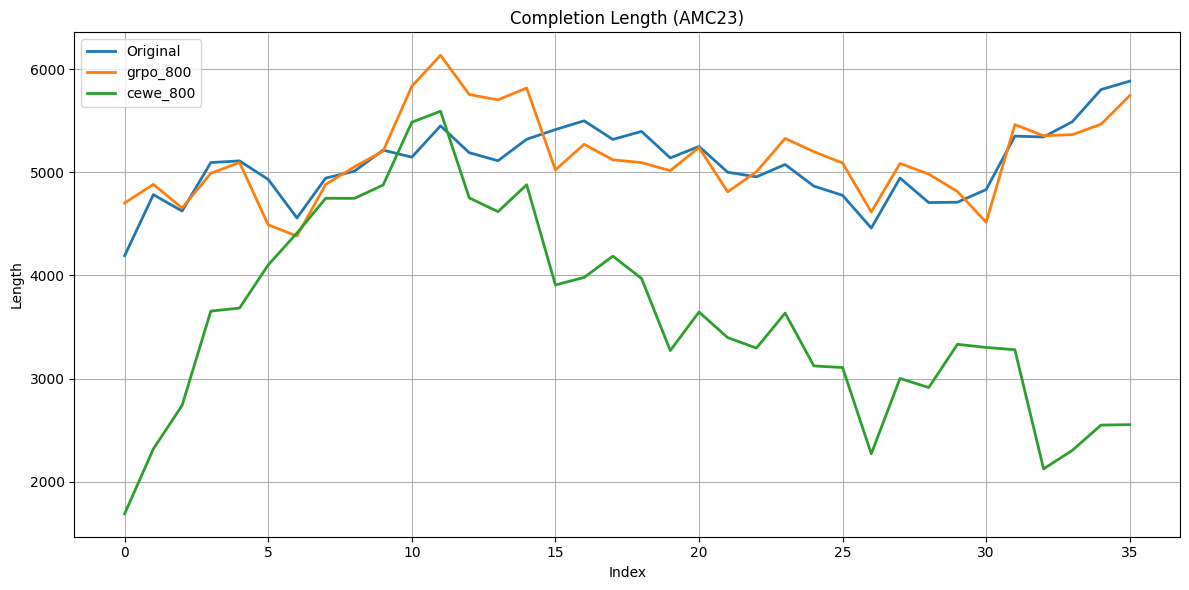

In [35]:
import matplotlib.pyplot as plt

# 绘制曲线图
plt.figure(figsize=(12, 6))
plt.plot(Avg_Original_lengths, label="Original", linewidth=2)
plt.plot(Avg_Grpo_lengths, label="grpo_800", linewidth=2)
plt.plot(Avg_Cewe_lengths, label="cewe_800", linewidth=2)

# 图例和标签
plt.title("Completion Length (AMC23)")
plt.xlabel("Index")
plt.ylabel("Length")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()